# Large Scale Ambiguity Example

Generating examples of large scale ambiguities through SSD process 
- Two areas where SSD shows strong covergence: however two different locations 


CHECKLIST 
- [ ] Import new ground images and satellite imagery
- [ ] Register desired image to sat pt 1
- [ ] Register desired image to sat pt 2

In [1]:
from groundNAV_agent import gNAV_agent
# from microp_distb import microp_distb
# from distb_plt_utils import microp_distb_plotter

import pycolmap

import numpy as np
import open3d as o3d
import copy
import pickle

# SAVE YOUR WORK
%load_ext autoreload
%autoreload 2
%autosave 180

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


Autosaving every 180 seconds


In [2]:
# Upload dataset inputs

# Colmap data
colm_fn = "../datasets/KBCB_colm/"

# Local test images 
# im_local = '../datasets/KBCB_test_images/' # With 10 local images 
# New local test image - frame 28599 NOT in COLMAP 
im_local = '../datasets/LSA_test_images/'


# Satellite reference image
# sat_ref = "../datasets/KBCB_satellite/KBCB_partial.jpg" # Public google earth satellite imagery
sat_ref = "../datasets/KBCB_satellite/KBCB_partial_LSA.png" # Public google earth satellite imagery



# Ground truth solutions
ind_params_KBCB = np.load("ind_params_KBCB_FULL.npy")

In [3]:
# Pose id for new frame
id_LSA = 121
# Starting scale and yaw from last KBCB ground truth solution
scale0, yaw0 = ind_params_KBCB[-1][0], ind_params_KBCB[-1][1]

# Candidate locations - satellite PIXEL coords (x, y) TODO: pick from KBCB_partial_LSA.png
sat_shift = np.array([700, 600]) # Same shift as sat_im_init
cands_px = {'A': (1000, 900),
            'B': (1500, 900)}
cand_params = {k: np.array([[scale0, yaw0, px - sat_shift[0], py - sat_shift[1]]])
               for k, (px, py) in cands_px.items()}

# Start with candidate A
ind_params = cand_params['A']

In [4]:
# Create class
gnav = gNAV_agent(colm_fn, im_local, sat_ref, ind_params)

# Borrow pose (image_parsing leaves unmatched ids at 0)
print("Parsed im_ids:", gnav.im_ids)
gnav.im_ids[0] = id_LSA
print("Borrowed:", gnav.im_ids, gnav.images_c[id_LSA].name)

Parsed im_ids: [0]
Borrowed: [121] frame_26999.jpg


#### Pose and GT solutions

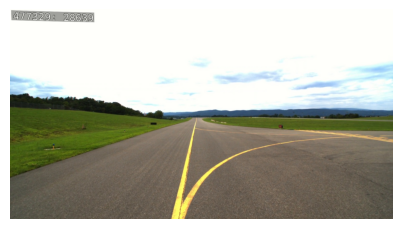

In [5]:
# VISUALIZER
gnav.visualize_local_ims()

In [6]:
# Using pre_calculated ground plane points - read explanation below 
pts_gnd_idx = np.load('../datasets/KBCB_params/ground_pts_idxs.npy')
gnav.pts_gnd_idx = pts_gnd_idx
# Run the ground plane extractor for visualization purposes 
pts_gnd_idx_test = gnav.get_gnd_pts() 
# # Visualize ground plane points 
# gnav.visualize_ground_pts(pts_gnd_idx_test) # UNCOMMENT for visualizations 

### Set ref frame

In [7]:
# Gather reference frame
tform_ref_frame = gnav.set_ref_frame() 
tform_ref_frame_pts = gnav.inv_homog_transform(tform_ref_frame)
gnav.tform_ref_frame_pts = tform_ref_frame_pts
print("\nReference frame transformation\n", tform_ref_frame_pts)

# Transform all points to the new coordinate system - for visual check 
tform_ref_frame_inv = gnav.inv_homog_transform(tform_ref_frame)
origin_ref, scene_pts_ref, scene_vec_ref = gnav.unit_vec_tform(gnav.scene_pts, gnav.origin_w, tform_ref_frame_inv)
gnav.scene_pts_ref = scene_pts_ref

Gravity vector 
 [-0.00516537  0.99923869  0.03866977]

Height h_0 =  0.09328363092429819

Reference frame transformation
 [[ 0.61692741  0.03361836 -0.7863017   0.20779018]
 [-0.7870031   0.01979491 -0.6166314  -0.15853791]
 [-0.00516537  0.99923869  0.03866977  0.90871723]
 [ 0.          0.          0.          1.        ]]


In [8]:
# Visualizer
gnav.visualize_ref_frame(scene_pts_ref)
# Optionally, view the direction of the gravity vector
# gnav.visualize_grav_vec()

878 1600 ytot xtot


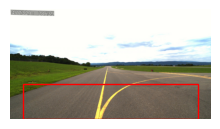

In [9]:
%matplotlib qt
# Prune points and create mask
# pts = gnav.prune_satellite_image()

# AUTOMATED PATCH EXTRACTION 
%matplotlib inline
# Initial size
params_tot = gnav.get_initial_params()
# Grab points and plot
gnav.grab_image_pts_tot(params_tot)
gnav.plot_gnd_pts()

In [10]:
# Generate projection of image sections 
for i in range(gnav.im_num):
    # Unit vectors in camera coords 
    pts_vec_c, pts_rgb_gnd = gnav.unit_vec_c(i)
    gnav.im_mosaic[i] = {'rgbc': pts_rgb_gnd}

    # Get transformation matrix that move from camera coords to world coords
    image_id = gnav.im_ids[i]
    # print(image_id)
    homog_w2c, homog_c2w = gnav.get_pose_id(image_id,i)
    # print('Homogeneous transformation from world to camera \n', homog_c2w)
    # print('\n Homogeneous transformation from camera to world \n', homog_w2c)

    # Transform to world coords
    origin_c, pts_loc_w, pts_vec_w = gnav.unit_vec_tform(pts_vec_c, gnav.origin_w, homog_c2w)
    # print('\n New camera frame origin = ', origin_c)
    
    # Get new points 
    ranges, new_pts_w = gnav.pt_range(pts_vec_w, homog_c2w, origin_c, i)
    # print('\nNew Points \n', new_pts_w)

    # Transfer points to reference frame
    __, new_pts_r, pts_vec_r = gnav.unit_vec_tform(new_pts_w, gnav.origin_w, gnav.tform_ref_frame_pts)

    # Convert points to grayscale 
    gray_c = gnav.conv_to_gray(gnav.im_mosaic[i]['rgbc'],i)
    # print(gray_c)

    # Put new points and grayscale colors in image mosaic
    gnav.im_mosaic[i]['pts'] = new_pts_r
    gnav.im_mosaic[i]['color_g'] = gray_c
    
    print("\nDone image ", i)


Done image  0


In [11]:
# Hand tuning: scale, rotation (deg), x, y - x, y in shifted sat frame (pixel - [700, 600])
scale, rot_deg, x, y = 140, 342, 760, 575

params_tune = np.array([[scale, np.deg2rad(rot_deg), x, y]])
gnav.implement_guess_ind(params_tune)

vis = o3d.visualization.Visualizer()
vis.create_window(window_name="Image patch with reference map (tuning)")
gnav.mosaic_w_ref_visualization(vis)


In [12]:
# SSD at hand-aligned locations
# Each entry: scale, rotation (deg), x, y - same as tuning cell
locs = {'loc1': (140, 336, 322, 320), 'loc2': (140, 335, 1565, 952)}

n_ssd = 5
ssds_locs = {}

for key, (scale, rot_deg, x, y) in locs.items():
    params = np.array([[scale, np.deg2rad(rot_deg), x, y]])
    gnav.implement_guess_ind(params)
    ssds_locs[key] = gnav.ssd_nxn(n_ssd, 0)
    # Min SSD and shift (ssds indexed [shiftx + n, shifty + n])
    idx = np.unravel_index(np.argmin(ssds_locs[key]), ssds_locs[key].shape)
    print(f"{key}: min SSD = {ssds_locs[key][idx]:.2f} at shift (x, y) = ({idx[0]-n_ssd}, {idx[1]-n_ssd})")


Number of points used for image 0:  (3902,)
loc1: min SSD = 17.72 at shift (x, y) = (-2, 0)
Number of points used for image 0:  (3897,)
loc2: min SSD = 22.52 at shift (x, y) = (4, 3)


In [13]:
import plotly.graph_objects as go

# SSD surface plots (plotly) for each location
x = np.linspace(-n_ssd, n_ssd, 2*n_ssd + 1)
Y, X = np.meshgrid(x, x) # ssds indexed [shiftx + n, shifty + n]

for key, ssds in ssds_locs.items():
    # Min SSD
    idrow, idcol = np.unravel_index(np.argmin(ssds), ssds.shape)
    print(f"BEST SHIFT for {key}:", idrow - n_ssd, idcol - n_ssd)

    fig = go.Figure()

    # SSD surface
    fig.add_surface(x=X, y=Y, z=ssds, colorscale='Viridis',
                    colorbar=dict(title='SSD'), name='SSD Surface')

    # Min SSD point
    fig.add_trace(go.Scatter3d(x=[idrow - n_ssd], y=[idcol - n_ssd], z=[ssds[idrow, idcol]],
                               mode='markers', marker=dict(size=6, color='red'), name='Min SSD'))

    # Aligned location (zero shift)
    fig.add_trace(go.Scatter3d(x=[0], y=[0], z=[ssds[n_ssd, n_ssd]],
                               mode='markers', marker=dict(size=6, color='black'), name='Hand aligned'))

    fig.update_layout(
        title=f'SSD Surface Plot: {key} {locs[key]}',
        scene=dict(
            xaxis=dict(title='X Shift (pixels)', range=[-n_ssd, n_ssd], dtick=1),
            yaxis=dict(title='Y Shift (pixels)', range=[-n_ssd, n_ssd], dtick=1),
            zaxis=dict(title='SSD'),
            camera=dict(eye=dict(x=1.5, y=1.5, z=1.2)),
            aspectmode='cube'
        ),
        width=900, height=800
    )
    fig.show()


BEST SHIFT for loc1: -2 0


BEST SHIFT for loc2: 4 3


In [14]:
# import cv2
# # Swap satellite reference on existing agent (projection unchanged)
# sat_ref_orig = "../datasets/KBCB_satellite/KBCB_partial.jpg"
# gnav.sat_ref_c = cv2.imread(sat_ref_orig)
# gnav.sat_ref = cv2.cvtColor(gnav.sat_ref_c, cv2.COLOR_BGR2GRAY)
# gnav.sat_im_init() # Rebuilds ref_pts, ref_rgb (same [700, 600] shift)
# print("Satellite:", gnav.sat_ref.shape)


In [15]:
# # SSD on original satellite image
# locs['loc3_orig'] = (140, 342, 760, 575) # TODO: tuned values from cell 15

# scale, rot_deg, x, y = locs['loc3_orig']
# gnav.implement_guess_ind(np.array([[scale, np.deg2rad(rot_deg), x, y]]))
# ssds_locs['loc3_orig'] = gnav.ssd_nxn(n_ssd, 0)

# idx = np.unravel_index(np.argmin(ssds_locs['loc3_orig']), ssds_locs['loc3_orig'].shape)
# print(f"loc3_orig: min SSD = {ssds_locs['loc3_orig'][idx]:.2f} at shift (x, y) = ({idx[0]-n_ssd}, {idx[1]-n_ssd})")


## Extended ROI
Extending the image ROI (currently bottom 278 rows) to capture more of the runway/T-intersection. Checking whether image resolution drops below satellite resolution in the far field.

Horizon row (approx): 442


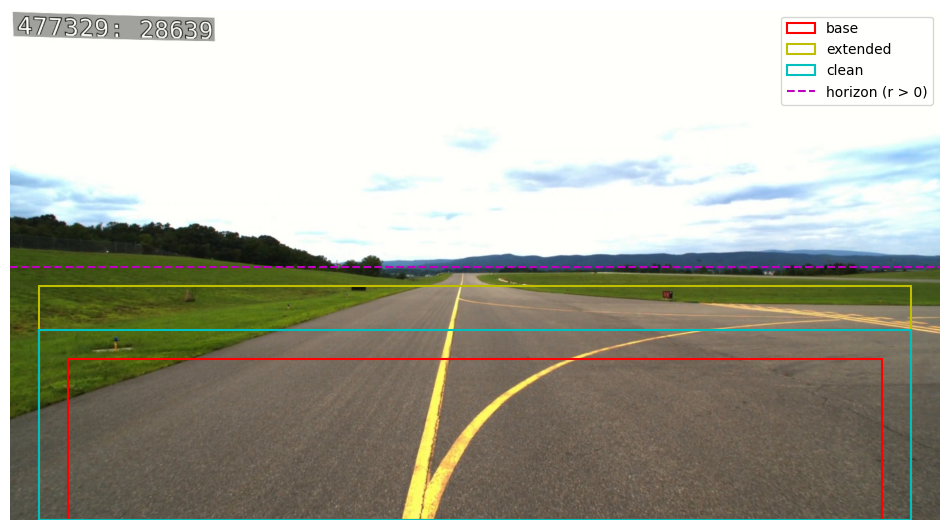

In [29]:
import matplotlib.pyplot as plt
import cv2

# Candidate ROIs: x, y, width, height
H, W = gnav.images_dict[0].shape[:2]
rois = {'base': (100, 600, W - 200, H - 600),
        'extended':  (50, 475, W - 100, H - 475),
        # 'far':  (0, 350, W, H - 350),
        'clean': (50, 550, W-100, H-550)}

# Horizon estimate: highest row (center column) where the ray still hits the ground (r > 0)
c2w = gnav.im_pts_2d[0]['c2w']
v = np.arange(H)
rays_c = np.stack([np.zeros(H), v - H/2, np.full(H, gnav.focal)], axis=1)
rays_w = rays_c @ c2w[:3, :3].T
r = (gnav.h_0 - c2w[:3, 3] @ gnav.grav_vec) / (rays_w @ gnav.grav_vec)
horizon_row = v[r > 0].min()
print("Horizon row (approx):", horizon_row)

# Plot
im = cv2.cvtColor(gnav.images_dict[0], cv2.COLOR_BGR2RGB)
plt.figure(figsize=(12, 7))
plt.imshow(im)
for (k, (x, y, w, h)), c in zip(rois.items(), ['r', 'y', 'c', 'b']):
    plt.gca().add_patch(plt.Rectangle((x, y), w, h, fill=False, edgecolor=c, lw=1.5, label=k))
plt.axhline(horizon_row, color='m', ls='--', label='horizon (r > 0)')
plt.legend()
plt.axis('off')
plt.show()

In [19]:
def project_roi(gnav, roi):
    """
    Grab ROI pixels and project onto the ground plane in the ref frame (same as cells 13-14)
    Input: roi (x, y, width, height)
    """
    gnav.grab_image_pts_tot(np.array([roi]))

    for i in range(gnav.im_num):
        # Unit vectors in camera coords
        pts_vec_c, pts_rgb_gnd = gnav.unit_vec_c(i)
        gnav.im_mosaic[i] = {'rgbc': pts_rgb_gnd}

        # Camera to world transform
        homog_w2c, homog_c2w = gnav.get_pose_id(gnav.im_ids[i], i)

        # Transform to world coords and intersect with ground plane
        origin_c, pts_loc_w, pts_vec_w = gnav.unit_vec_tform(pts_vec_c, gnav.origin_w, homog_c2w)
        ranges, new_pts_w = gnav.pt_range(pts_vec_w, homog_c2w, origin_c, i)

        # Transfer points to reference frame
        __, new_pts_r, pts_vec_r = gnav.unit_vec_tform(new_pts_w, gnav.origin_w, gnav.tform_ref_frame_pts)

        # Store points and grayscale colors
        gnav.im_mosaic[i]['pts'] = new_pts_r
        gnav.im_mosaic[i]['color_g'] = gnav.conv_to_gray(gnav.im_mosaic[i]['rgbc'], i)

        # Image row of each point (same flattening order as pts) - for resolution check by row band
        gnav.im_mosaic[i]['rows'] = gnav.im_pts_2d[i]['pts'][..., 1].ravel()

        # Range check - r <= 0 means ray is at/above horizon
        r = gnav.im_pts_2d[i]['r']
        print(f"Image {i}: {r.size} pts, range min/max = {r.min():.3f}/{r.max():.3f}, "
              f"max/min = {r.max()/r.min():.1f}, r <= 0: {(r <= 0).sum()}")


Image 0: 604500 pts, range min/max = 0.276/3.907, max/min = 14.2, r <= 0: 0


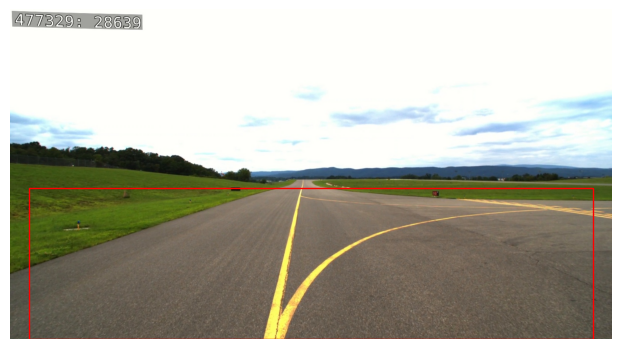

In [22]:
project_roi(gnav, rois['mid'])
gnav.plot_gnd_pts()


In [24]:
# Visualize extended ROI at a hand-aligned location
key = 'loc2'
scale, rot_deg, x, y = locs[key]
gnav.implement_guess_ind(np.array([[scale, np.deg2rad(rot_deg), x, y]]))

vis = o3d.visualization.Visualizer()
vis.create_window(window_name=f"Extended ROI with reference map ({key})")
gnav.mosaic_w_ref_visualization(vis)



loc1: 92096 sat px, overall repeat ratio = 0.273
      rows   n_sat  repeat  d_mean   d_max   d>0.7
 475-500     57036   0.438   2.198   6.843   0.827
 500-525     18203   0.008   0.890   2.421   0.591
 525-550      7144   0.000   0.467   1.180   0.230
 550-575      3516   0.000   0.289   0.685   0.000
 575-600      1990   0.000   0.197   0.444   0.000
 600-625      1231   0.000   0.143   0.321   0.000
 625-650       816   0.000   0.109   0.239   0.000
 650-675       570   0.000   0.086   0.181   0.000
 675-700       408   0.000   0.069   0.143   0.000
 700-725       310   0.000   0.058   0.117   0.000
 725-750       236   0.000   0.048   0.098   0.000
 750-775       182   0.000   0.042   0.082   0.000
 775-800       148   0.000   0.035   0.069   0.000
 800-825       119   0.000   0.030   0.063   0.000
 825-850        99   0.000   0.027   0.050   0.000
 850-875        81   0.000   0.024   0.047   0.000
 875-900         7   0.000   0.024   0.037   0.000

loc2: 105420 sat px, overall re

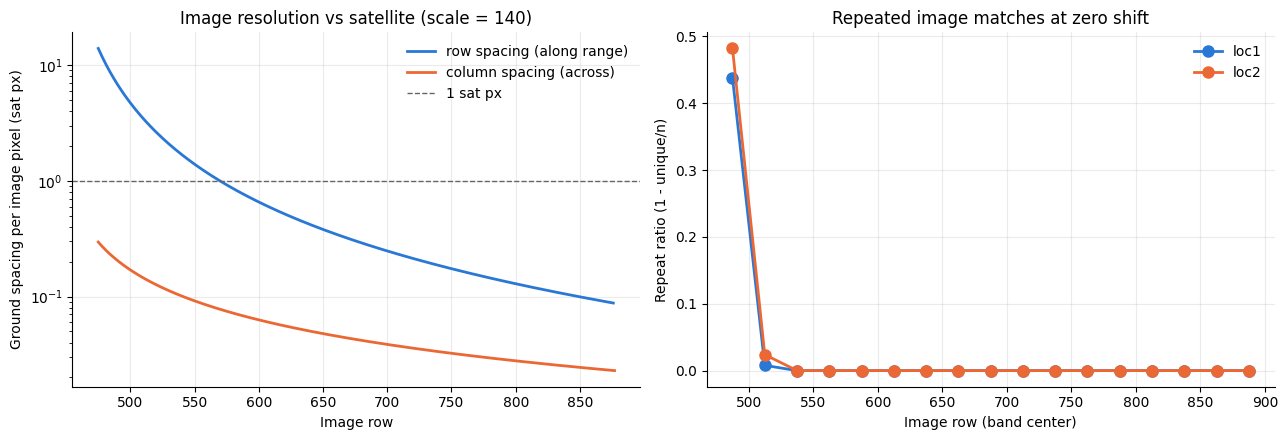

In [25]:
from scipy.spatial import cKDTree

# Resolution check on extended ROI: image pixel spacing vs satellite pixels
roi = rois['mid']
x0, y0, w, h = roi
band = 25 # Image rows per band
band_edges = np.arange(y0, y0 + h + band, band)
rows_im = gnav.im_mosaic[0]['rows']

res = {}
for key, (scale, rot_deg, x, y) in locs.items():
    gnav.implement_guess_ind(np.array([[scale, np.deg2rad(rot_deg), x, y]]))
    pts_bg = gnav.im_pts_best_guess[0]['pts'][:, :2] # In satellite pixel units

    # 1. Spacing between neighboring image pixels (median per image row)
    grid = pts_bg.reshape(h, w, 2)
    row_sp = np.median(np.linalg.norm(np.diff(grid, axis=0), axis=-1), axis=1) # Between row v and v+1
    col_sp = np.median(np.linalg.norm(np.diff(grid, axis=1), axis=-1), axis=1) # Between columns, within row v

    # 2. Repeated matches at zero shift (same query as ssd_nxn)
    inside_pts, __ = gnav.get_inside_sat_pts(0, 0, 0)
    dists, idxs = cKDTree(pts_bg).query(inside_pts[:, :2], k=1)
    matched_rows = rows_im[idxs]

    print(f"\n{key}: {len(idxs)} sat px, overall repeat ratio = {1 - np.unique(idxs).size/len(idxs):.3f}")
    print(f"{'rows':>10} {'n_sat':>7} {'repeat':>7} {'d_mean':>7} {'d_max':>7} {'d>0.7':>7}")
    bands = []
    for lo, hi in zip(band_edges[:-1], band_edges[1:]):
        m = (matched_rows >= lo) & (matched_rows < hi)
        n = m.sum()
        if n == 0:
            continue
        rep = 1 - np.unique(idxs[m]).size / n
        far = np.mean(dists[m] > 0.7)
        bands.append((lo, hi, n, rep))
        print(f"{lo:>4}-{hi:<5} {n:>7} {rep:>7.3f} {dists[m].mean():>7.3f} {dists[m].max():>7.3f} {far:>7.3f}")

    res[key] = {'row_sp': row_sp, 'col_sp': col_sp, 'bands': np.array(bands)}

# Plot: spacing per image row (left), repeat ratio per band (right)
fig, axs = plt.subplots(1, 2, figsize=(13, 4.5))
rows_v = np.arange(y0, y0 + h)
sp = res['loc1']
axs[0].plot(rows_v[:-1], sp['row_sp'], color='#2a78d6', lw=2, label='row spacing (along range)')
axs[0].plot(rows_v, sp['col_sp'], color='#eb6834', lw=2, label='column spacing (across)')
axs[0].axhline(1, color='0.4', ls='--', lw=1, label='1 sat px')
axs[0].set_yscale('log')
axs[0].set_xlabel('Image row')
axs[0].set_ylabel('Ground spacing per image pixel (sat px)')
axs[0].set_title('Image resolution vs satellite (scale = 140)')
axs[0].legend(frameon=False)

for key, c in zip(res, ['#2a78d6', '#eb6834']):
    b = res[key]['bands']
    axs[1].plot((b[:, 0] + b[:, 1]) / 2, b[:, 3], color=c, lw=2, marker='o', ms=8, label=key)
axs[1].set_xlabel('Image row (band center)')
axs[1].set_ylabel('Repeat ratio (1 - unique/n)')
axs[1].set_title('Repeated image matches at zero shift')
axs[1].legend(frameon=False)

for ax in axs:
    ax.grid(alpha=0.25)
    ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()



===== ROI: clean (50, 550, 1500, 328) =====
Image 0: 492000 pts, range min/max = 0.276/1.189, max/min = 4.3, r <= 0: 0
Number of points used for image 0:  (9618,)
Number of points used for image 0:  (9620,)

===== ROI: extended (50, 475, 1500, 403) =====
Image 0: 604500 pts, range min/max = 0.276/3.907, max/min = 14.2, r <= 0: 0
Number of points used for image 0:  (93109,)
Number of points used for image 0:  (105420,)

   roi   loc   n_sat   min SSD  mean SD    shift
  base  loc1    3902     17.72   0.0045 (-2,  0)
  base  loc2    3897     22.52   0.0058 ( 4,  3)
 clean  loc1    9618     47.25   0.0049 (-4, -1)
 clean  loc2    9620     66.05   0.0069 (-2,  0)
extended  loc1   92096   1578.57   0.0171 ( 5,  4)
extended  loc2  105420   1397.78   0.0133 ( 5,  3)


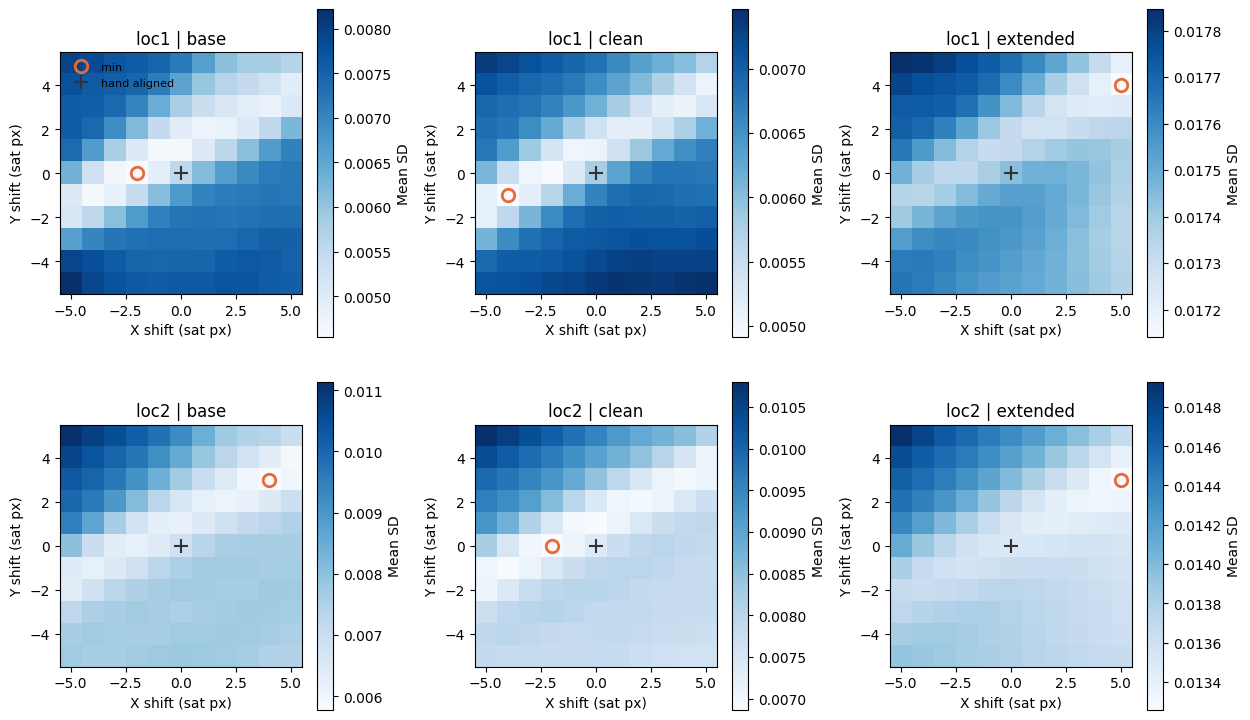

Image 0: 604500 pts, range min/max = 0.276/3.907, max/min = 14.2, r <= 0: 0


In [32]:
# SSD on extended ROIs (no mitigation) - compare against baseline (ssds_locs)
rois['clean'] = (50, 550, W - 100, H - 550)

ssds_ext = {'base': ssds_locs}
n_sat = {}
for roi_key in ['clean', 'extended']:
    print(f"\n===== ROI: {roi_key} {rois[roi_key]} =====")
    project_roi(gnav, rois[roi_key])
    ssds_ext[roi_key] = {}
    for key, (scale, rot_deg, x, y) in locs.items():
        gnav.implement_guess_ind(np.array([[scale, np.deg2rad(rot_deg), x, y]]))
        ssds_ext[roi_key][key] = gnav.ssd_nxn(n_ssd, 0)
        # Sat px count at zero shift - approximate normalizer (count varies slightly with shift)
        n_sat[(roi_key, key)] = len(gnav.get_inside_sat_pts(0, 0, 0)[0])

n_sat[('base', 'loc1')], n_sat[('base', 'loc2')] = 3902, 3897 # From cell 16 output

# Summary
print(f"\n{'roi':>6} {'loc':>5} {'n_sat':>7} {'min SSD':>9} {'mean SD':>8} {'shift':>8}")
for roi_key, d in ssds_ext.items():
    for key, ssds in d.items():
        i, j = np.unravel_index(np.argmin(ssds), ssds.shape)
        n = n_sat[(roi_key, key)]
        print(f"{roi_key:>6} {key:>5} {n:>7} {ssds[i, j]:>9.2f} {ssds[i, j]/n:>8.4f} ({i-n_ssd:>2}, {j-n_ssd:>2})")

# Heatmaps: rows = location, cols = ROI (mean SD, own color scale per panel)
roi_keys = list(ssds_ext)
fig, axs = plt.subplots(len(locs), len(roi_keys), figsize=(4.2*len(roi_keys), 3.8*len(locs)))
ext = [-n_ssd - 0.5, n_ssd + 0.5, -n_ssd - 0.5, n_ssd + 0.5]
for r, key in enumerate(locs):
    for c, roi_key in enumerate(roi_keys):
        ax = axs[r, c]
        msd = ssds_ext[roi_key][key] / n_sat[(roi_key, key)]
        im_h = ax.imshow(msd.T, origin='lower', extent=ext, cmap='Blues') # Transpose: x shift horizontal
        i, j = np.unravel_index(np.argmin(msd), msd.shape)
        ax.plot(i - n_ssd, j - n_ssd, 'o', ms=9, mfc='none', mec='#eb6834', mew=2, label='min')
        ax.plot(0, 0, '+', ms=10, color='0.2', mew=1.5, label='hand aligned')
        ax.set_title(f"{key} | {roi_key}")
        ax.set_xlabel('X shift (sat px)')
        ax.set_ylabel('Y shift (sat px)')
        fig.colorbar(im_h, ax=ax, label='Mean SD')
axs[0, 0].legend(frameon=False, loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()

# Restore extended ROI used in the resolution check
project_roi(gnav, rois['extended'])


### Footprint-matched SSD
Compare patch to patch instead of pixel to pixel. Image pixels are grouped into cells covering ~1 sat px of ground (or more). For each shift, sat pixels are averaged within each cell and compared to the cell's mean image intensity - one SSD term per cell.

In [33]:
def build_cells(gnav, roi, scale, target=1.0):
    """
    Group image pixels into cells covering >= ~target sat px of ground in both directions
    Input: roi (x, y, width, height) used in project_roi, scale (ref frame -> sat px), target (sat px)
    Output: cell id for each projected point (same order as im_mosaic pts), number of cells
    """
    x0, y0, w, h = roi
    # Projected points in sat px units, back on the image grid (row-major, same as unit_vec_c)
    # Rotation/translation don't change spacing, so scale is all that's needed
    grid = gnav.im_mosaic[0]['pts'][:, :2].reshape(h, w, 2) * scale

    # Median ground spacing per image row
    row_sp = np.median(np.linalg.norm(np.diff(grid, axis=0), axis=-1), axis=1) # Row v to v+1 (h-1)
    col_sp = np.median(np.linalg.norm(np.diff(grid, axis=1), axis=-1), axis=1) # Within row v (h)

    # Row groups: new group each time accumulated row spacing passes target
    # Far rows (row_sp > target) each get their own group
    cum = np.concatenate([[0], np.cumsum(row_sp)])
    __, row_grp = np.unique(np.floor(cum / target), return_inverse=True)

    # Column groups: k adjacent columns so cell width >= target (k = 1 if already wide enough)
    n_grp = row_grp.max() + 1
    col_sp_grp = np.bincount(row_grp, weights=col_sp) / np.bincount(row_grp)
    k_grp = np.maximum(1, np.round(target / col_sp_grp)).astype(int)
    col_grp = np.arange(w)[None, :] // k_grp[row_grp][:, None] # (h, w)

    # Unique cell id per (row group, column group)
    pairs = np.stack([np.repeat(row_grp, w), col_grp.ravel()], axis=1)
    __, cell_id = np.unique(pairs, axis=0, return_inverse=True)
    cell_id = cell_id.ravel()
    n_cells = cell_id.max() + 1

    print(f"Cells: {n_cells} | row groups: {n_grp} | columns per cell: {k_grp.min()}-{k_grp.max()}")
    return cell_id, n_cells


def ssd_footprint(gnav, n, cell_id, n_cells):
    """
    Footprint-matched SSD: one term per cell (mean sat vs mean image over the same ground)
    Same brightness offset and clipping as ssd_nxn, applied per pixel before averaging
    Input: n shift amount, cell ids and count from build_cells
    Output: mean SD per cell for each shift, number of cells used for each shift
    """
    # Brightness offset (same as ssd_nxn)
    sat_bestcase = 0.5576082
    gnd_bestcase = 0.38640129
    bc_diff = sat_bestcase - gnd_bestcase

    # Mean image intensity per cell - doesn't change with shift, computed once
    gray = np.minimum(gnav.im_mosaic[0]['color_g'][:, 0], 1 - bc_diff)
    cell_im = np.bincount(cell_id, weights=gray, minlength=n_cells) / np.bincount(cell_id, minlength=n_cells)

    # Tree on unshifted image points - shifting image by +s is the same as querying sat pts at -s
    loc_pts = gnav.im_pts_best_guess[0]['pts'][:, :2]
    tree = cKDTree(loc_pts)

    msd = np.zeros((2*n+1, 2*n+1))
    ncell = np.zeros((2*n+1, 2*n+1), dtype=int)
    for shiftx in range(-n, n+1):
        for shifty in range(-n, n+1):
            # Sat pixels inside shifted image footprint (same as ssd_nxn)
            inside_pts, inside_cg = gnav.get_inside_sat_pts(0, shiftx, shifty)
            sat = np.maximum(inside_cg[:, 0] - bc_diff, 0)

            # Nearest image pixel -> its cell
            __, idxs = tree.query(inside_pts[:, :2] - np.array([shiftx, shifty]), k=1)
            c = cell_id[idxs]

            # Mean sat intensity per cell (only cells that received sat px)
            cnt = np.bincount(c, minlength=n_cells)
            valid = cnt > 0
            cell_sat = np.bincount(c, weights=sat, minlength=n_cells)[valid] / cnt[valid]

            # One term per cell, averaged with this shift's exact cell count
            msd[shiftx + n, shifty + n] = np.mean((cell_sat - cell_im[valid])**2)
            ncell[shiftx + n, shifty + n] = valid.sum()

    return msd, ncell


===== ROI: clean (50, 550, 1500, 328) =====
Image 0: 492000 pts, range min/max = 0.276/1.189, max/min = 4.3, r <= 0: 0
Cells: 9555 | row groups: 112 | columns per cell: 11-43
loc1: min mean SD = 0.0039 at shift (-2, 0), cells used = 8113 (range 8113-8113)
Cells: 9555 | row groups: 112 | columns per cell: 11-43
loc2: min mean SD = 0.0058 at shift (-2, 0), cells used = 8168 (range 8168-8168)

===== ROI: extended (50, 475, 1500, 403) =====
Image 0: 604500 pts, range min/max = 0.276/3.907, max/min = 14.2, r <= 0: 0
Cells: 27408 | row groups: 187 | columns per cell: 3-43
loc1: min mean SD = 0.0112 at shift (5, 4), cells used = 24935 (range 24745-24935)
Cells: 27408 | row groups: 187 | columns per cell: 3-43
loc2: min mean SD = 0.0121 at shift (5, 3), cells used = 26049 (range 26049-26049)


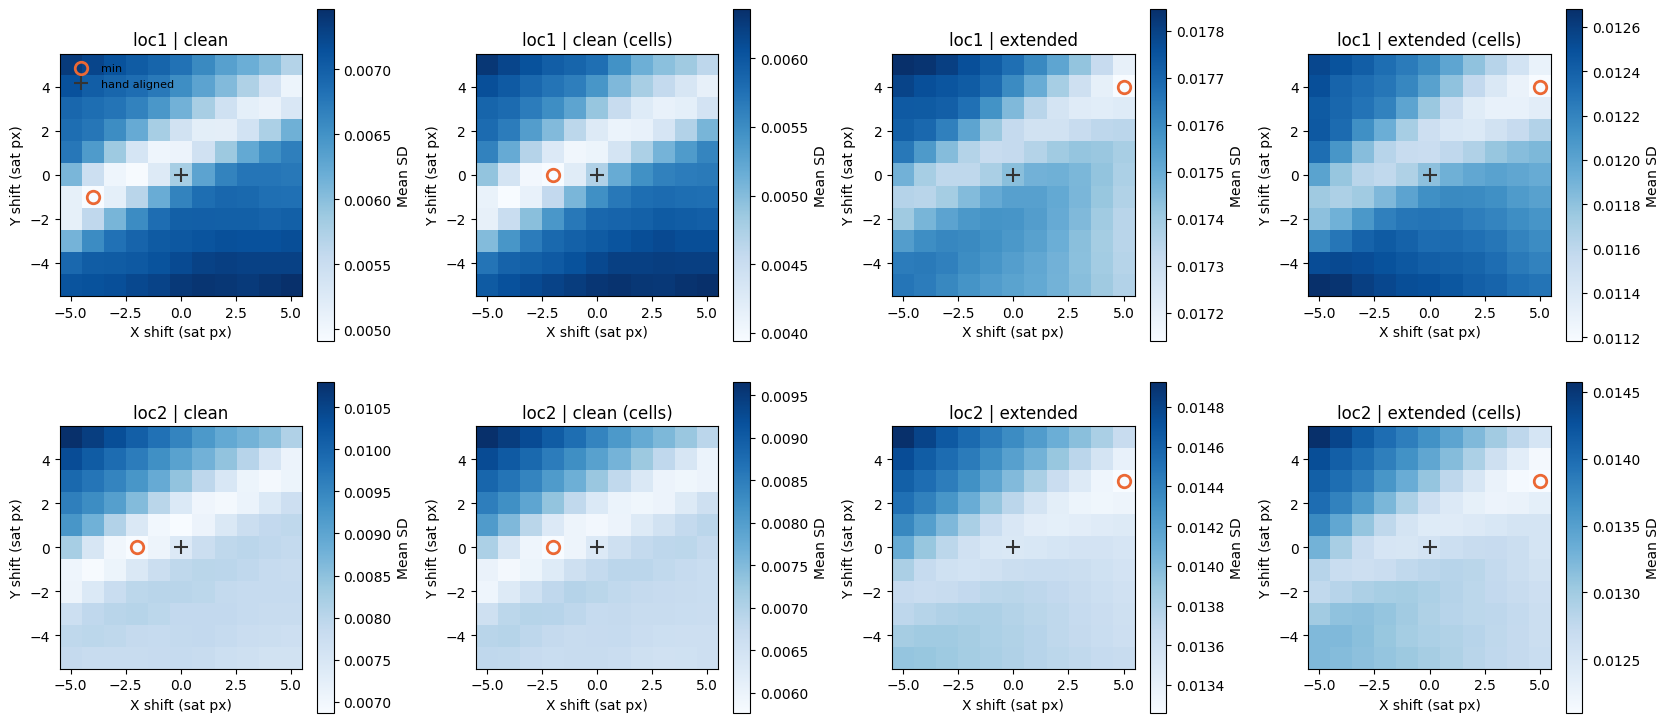

            clean: loc2/loc1 = 1.40
    clean (cells): loc2/loc1 = 1.46
         extended: loc2/loc1 = 0.77
 extended (cells): loc2/loc1 = 1.08


In [34]:
# Footprint-matched SSD on clean and extended ROIs
msd_fp = {}
for roi_key in ['clean', 'extended']:
    print(f"\n===== ROI: {roi_key} {rois[roi_key]} =====")
    project_roi(gnav, rois[roi_key])
    msd_fp[roi_key] = {}
    for key, (scale, rot_deg, x, y) in locs.items():
        gnav.implement_guess_ind(np.array([[scale, np.deg2rad(rot_deg), x, y]]))
        cell_id, n_cells = build_cells(gnav, rois[roi_key], scale)
        msd, ncell = ssd_footprint(gnav, n_ssd, cell_id, n_cells)
        msd_fp[roi_key][key] = msd
        i, j = np.unravel_index(np.argmin(msd), msd.shape)
        print(f"{key}: min mean SD = {msd[i, j]:.4f} at shift ({i-n_ssd}, {j-n_ssd}), "
              f"cells used = {ncell[i, j]} (range {ncell.min()}-{ncell.max()})")

# Heatmaps: rows = location, cols = method/ROI (own color scale per panel - compare shapes, not colors)
panels = {'clean': lambda k: ssds_ext['clean'][k] / n_sat[('clean', k)],
          'clean (cells)': lambda k: msd_fp['clean'][k],
          'extended': lambda k: ssds_ext['extended'][k] / n_sat[('extended', k)],
          'extended (cells)': lambda k: msd_fp['extended'][k]}
fig, axs = plt.subplots(len(locs), len(panels), figsize=(4.2*len(panels), 3.8*len(locs)))
ext = [-n_ssd - 0.5, n_ssd + 0.5, -n_ssd - 0.5, n_ssd + 0.5]
for r, key in enumerate(locs):
    for c, (name, get) in enumerate(panels.items()):
        ax = axs[r, c]
        m = get(key)
        im_h = ax.imshow(m.T, origin='lower', extent=ext, cmap='Blues') # Transpose: x shift horizontal
        i, j = np.unravel_index(np.argmin(m), m.shape)
        ax.plot(i - n_ssd, j - n_ssd, 'o', ms=9, mfc='none', mec='#eb6834', mew=2, label='min')
        ax.plot(0, 0, '+', ms=10, color='0.2', mew=1.5, label='hand aligned')
        ax.set_title(f"{key} | {name}")
        ax.set_xlabel('X shift (sat px)')
        ax.set_ylabel('Y shift (sat px)')
        fig.colorbar(im_h, ax=ax, label='Mean SD')
axs[0, 0].legend(frameon=False, loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()

# loc2 / loc1 separation at each method's minimum (> 1 means loc1 matches better)
for name, get in panels.items():
    print(f"{name:>17}: loc2/loc1 = {get('loc2').min() / get('loc1').min():.2f}")